In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgb
from great_tables import GT, from_column, style, loc
from collections import Counter

# from sklearn import datasets
# Modelado
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    log_loss,
    recall_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from IPython.display import display, Markdown

# Funciones adicionales:
from functions import (
    plot_distribution,
    plot_calibration_models,
    plot_calibration,
    calibrate_model,
    calibration_table,
    calculate_clf_metrics,
)

import sklearn

sklearn.set_config(transform_output="pandas")

In [2]:
import matplotlib
import great_tables
from IPython.display import display, Markdown, Latex

In [3]:
color_verde = "#255255"
color_verde_claro = "#BDCBCC"

In [4]:
PATH_DATA = "https://raw.githubusercontent.com/karbartolome/workshops/main/20240513-uba-calibracion/df_german_credit.csv"
TARGET = "Risk"
df = (
    pd.read_csv(PATH_DATA)
    .drop("Unnamed: 0", axis=1)
    .assign(Risk=lambda x: np.where(x["Risk"] == "good", 0, 1))
)

In [5]:
# | tbl-cap: "Datos de German Credit (muestra de 6 observaciones)"
# | label: tbl-credit-data
def map_color(data):
    return (data[TARGET] == 1).map({True: color_verde_claro, False: "white"})

(
    GT(df.sample(6, random_state=123).set_index(TARGET).reset_index())
    .fmt_currency(columns="Credit amount")
    .tab_style(
        style=style.fill(color=map_color),
        locations=loc.body(columns=df.columns.tolist()),
    )
    .tab_style(
        style=style.text(color="red", weight="bold"),
        locations=loc.body(TARGET),
    )
    .tab_options(
        column_labels_background_color=color_verde, table_font_names="Times New Roman"
    )
)

Risk,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,29,male,2,own,little,little,"$6,887.00",36,education
1,21,male,2,rent,little,little,$902.00,12,education
0,29,male,1,own,,moderate,"$2,333.00",24,furniture/equipment
1,20,female,2,rent,little,little,"$2,039.00",18,furniture/equipment
0,35,male,2,own,,moderate,"$2,728.00",15,radio/TV
0,23,male,2,own,,moderate,"$1,444.00",15,radio/TV


In [6]:
# | label: particiones
# | results: 'asis'
y = df[TARGET]
X = df.drop([TARGET], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42
)

# Lo ideal es utilizar la partición de validación para calibración
X_valid, X_test, y_valid, y_test = train_test_split(
    X_test, y_test, test_size=0.5, shuffle=True, stratify=y_test, random_state=42
)

display(Markdown(f"N observaciones en entrenamiento: {X_train.shape[0]}"))
display(Markdown(f"N observaciones en validación: {X_valid.shape[0]}"))
display(Markdown(f"N observaciones en evaluación: {X_test.shape[0]}"))

N observaciones en entrenamiento: 500

N observaciones en validación: 250

N observaciones en evaluación: 250

In [7]:
numeric_transformer = Pipeline(
    [("impute", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]
)

categorical_transformer = Pipeline(
    [
        (
            "ohe",
            OneHotEncoder(
                min_frequency=0.05,
                drop="if_binary",
                handle_unknown="infrequent_if_exist",
                sparse_output=False,
            ),
        )
    ]
)

preproc = ColumnTransformer(
    [
        (
            "num",
            numeric_transformer,
            make_column_selector(dtype_include=["float", "int"]),
        ),
        (
            "cat",
            categorical_transformer,
            make_column_selector(dtype_include=["object", "category"]),
        ),
    ],
    verbose_feature_names_out=False,
)

In [8]:
display(GT(preproc.fit_transform(X_train).sample(2).round(2))
    .tab_options(
        column_labels_background_color=color_verde,
        table_font_names="Times New Roman"
    )
)

Age,Job,Credit amount,Duration,Sex_male,Housing_free,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Saving accounts_nan,Checking account_little,Checking account_moderate,Checking account_rich,Checking account_nan,Purpose_business,Purpose_car,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_infrequent_sklearn
0.12,1.0,0.3,0.57,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
0.05,0.67,0.15,0.25,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
def gen_pipe(model):
    pipe = Pipeline([
        ('preproc', preproc),
        ('model',model)
    ])
    return pipe

In [10]:
pipe_hist = gen_pipe(
    model = HistGradientBoostingClassifier(
        max_depth=4, learning_rate=0.1, max_iter=1000,
        random_state=42,
    )
)
pipe_hist_balanced = gen_pipe(
    model = HistGradientBoostingClassifier(
        max_depth=4, learning_rate=0.1, max_iter=1000, class_weight='balanced',
        random_state=42, 
    )
)
pipe_tree = gen_pipe(model = DecisionTreeClassifier(random_state=42))
pipe_reglog = gen_pipe(model = LogisticRegression(random_state=42))
pipe_reglog_balanced = gen_pipe(model = LogisticRegression(random_state=42, class_weight='balanced'))
pipe_svc = gen_pipe(model = SVC(random_state=42, probability=True))

In [11]:
models_dict = {
    'Regresión logística': pipe_reglog,
    'Hist gradient boosting': pipe_hist,
    #'Hist gradient boosting (balanceado)': pipe_hist_balanced
}

for i in models_dict.keys():
    models_dict.get(i).fit(X_train, y_train)

metrics_df = pd.DataFrame()
for i in models_dict.keys():
    pipe = models_dict.get(i)
    preds = pd.DataFrame({
        'y_true': y_test,
        'y_pred': pipe.predict(X_test),
        'y_pred_prob': pipe.predict_proba(X_test)[:,1],
    })
    m = calculate_clf_metrics(
        preds['y_true'], preds['y_pred'], preds['y_pred_prob'], 
        name=i
    ).reset_index().rename({'index':'Modelo'},axis=1)
    metrics_df = pd.concat([metrics_df, m], axis=0)

In [12]:
(GT(metrics_df.round(2))
    .data_color(
        columns=['Accuracy','Precision','Recall','F1','ROC AUC'],
        palette=[color_verde_claro, color_verde]
    )
    .data_color(
        columns=['Log Loss','Brier Loss'], palette=['white', 'darkred']
    )
    .tab_spanner(
        label="Clasificación",
        columns=["Accuracy","Recall","Precision","F1"]
    )
    .tab_spanner(
        label="Ordenamiento",
        columns=["ROC AUC"]
    )
    .tab_spanner(
        label="Probabilidad",
        columns=["Log Loss", "Brier Loss"]
    )
)

GT(_tbl_data=                   Modelo  Accuracy  Precision  Recall    F1  ROC AUC  \
0     Regresión logística      0.74       0.59    0.45  0.51     0.75   
0  Hist gradient boosting      0.72       0.53    0.53  0.53     0.74   

   Log Loss  Brier Loss  
0      0.53        0.18  
0      0.93        0.22  , _body=<great_tables._gt_data.Body object at 0x141a5e4d0>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Recall', type=<ColInfoTypeEnum.default: 1>, column_label='Recall', column_align='right', column_width=None), ColInfo(var='Precision', type=<ColInfoTypeEnum.default: 1>, column_label='Precision', column_align='right', column_width=None), ColInfo(var='F1', type=<ColInfoTypeEnum.default: 1>, column_label='F1', column_align='right', column_width=None), ColInfo(var='ROC AUC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC AUC', column_align='right', column_width=None), ColInfo(var='Log Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Log Loss', column_align='right', column_width=None), ColInfo(var='Brier Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Brier Loss', column_align='right', column_width=None)]), _stub=Stub([RowInfo(rownum_i=0, group_id=None, rowname=None, group_label=None, built=False), RowInfo(rownum_i=1, group_id=None, rowname=None, group_label=None, built=False)]), _row_groups=[], _group_rows=GroupRows([]), _spanners=Spanners([SpannerInfo(spanner_id='Clasificación', spanner_level=0, spanner_label='Clasificación', spanner_units=None, spanner_pattern=None, vars=['Accuracy', 'Recall', 'Precision', 'F1'], built=None), SpannerInfo(spanner_id='Ordenamiento', spanner_level=0, spanner_label='Ordenamiento', spanner_units=None, spanner_pattern=None, vars=['ROC AUC'], built=None), SpannerInfo(spanner_id='Probabilidad', spanner_level=0, spanner_label='Probabilidad', spanner_units=None, spanner_pattern=None, vars=['Log Loss', 'Brier Loss'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate

In [13]:
preds_df = (pd.DataFrame({
        'y_obs':y_test,
        'y_pred':pipe_hist.predict_proba(X_test)[:,1]
    })
    .assign(bin=lambda x: pd.qcut(x['y_pred'],q=5, precision=5))
)
preds_df['bin'] = pd.IntervalIndex(preds_df['bin']).map(lambda x: pd.Interval(round(x.left, 2), round(x.right, 2)))
(GT(preds_df
    .sample(5, random_state=123).round(4))
    .tab_options(
        column_labels_background_color=color_verde,
        table_font_names="Times New Roman"
    )
)

y_obs,y_pred,bin
0,0.1315,"(0.02, 0.23]"
0,0.0,"(-0.0, 0.0]"
1,0.6428,"(0.23, 0.84]"
0,0.0019,"(0.0, 0.02]"
0,0.0,"(-0.0, 0.0]"


In [14]:
(GT(preds_df.groupby('bin')
    .agg(
        N = ('y_obs','count'), 
        frac_positive=('y_obs','mean'),
        avg_pred = ('y_pred','mean')
    ).round(2).reset_index()
    )
    .tab_options(
        column_labels_background_color=color_verde,
        table_font_names="Times New Roman"
    )
)

bin,N,frac_positive,avg_pred
"(-0.0, 0.0]",50,0.08,0.0
"(0.0, 0.02]",50,0.14,0.01
"(0.02, 0.23]",50,0.28,0.08
"(0.23, 0.84]",50,0.4,0.51
"(0.84, 1.0]",50,0.6,0.95


/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0.1, 'Sobreestimación')

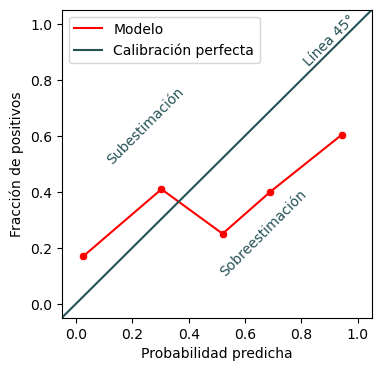

In [28]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(
    y_test, pipe_hist.predict_proba(X_test)[:,1], 
    n_bins=5,
    strategy='uniform'
)
plt.figure(figsize=(4,4))
sns.lineplot(x=prob_pred, y=prob_true, color='red', label='Modelo')
sns.scatterplot(x=prob_pred, y=prob_true, color='red')
plt.axline([0, 0], [1, 1], label="Calibración perfecta", c=color_verde)
plt.text(0.8, 0.85, "Línea 45°", fontsize=10, rotation=45, c=color_verde)

plt.legend()
plt.xlabel("Probabilidad predicha")
plt.ylabel("Fracción de positivos")
plt.text(0.10, 0.50, "Subestimación", fontsize=10, rotation=45, color=color_verde)
plt.text(0.50, 0.10, "Sobreestimación", fontsize=10, rotation=45, color=color_verde)

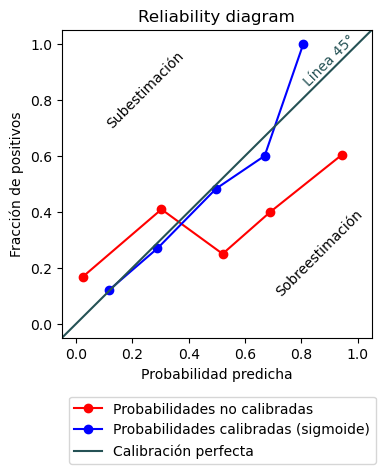

/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


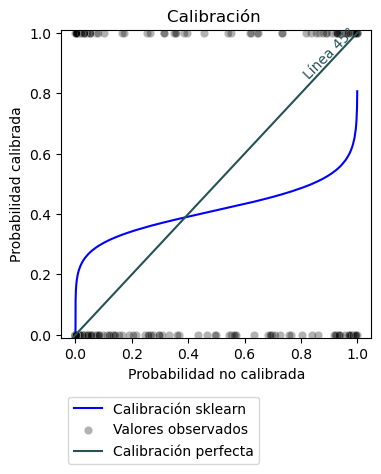

In [16]:
pipe_sigmoid_hist, _, preds_hist = calibrate_model(
    pipe=pipe_hist,
    X_valid=X_valid, y_valid=y_valid, 
    X_test=X_test, y_test=y_test,
    cal_sigmoid=True,
    cal_isotonic=False,
    model_name=''
)
plot_calibration(
    preds=preds_hist,
    y_pred_prob_calibrated='pred_sigmoid',
    model_name=''
)

## Regresión logística

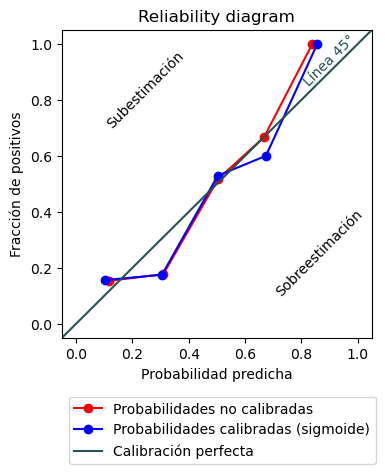

/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


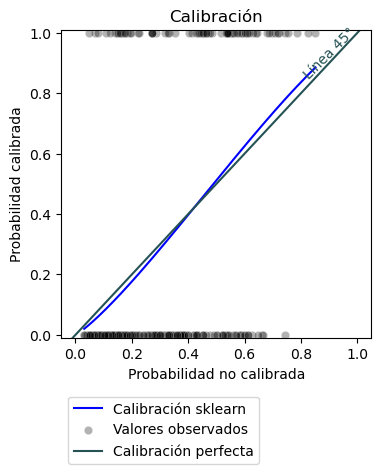

## Hist gradient boosting

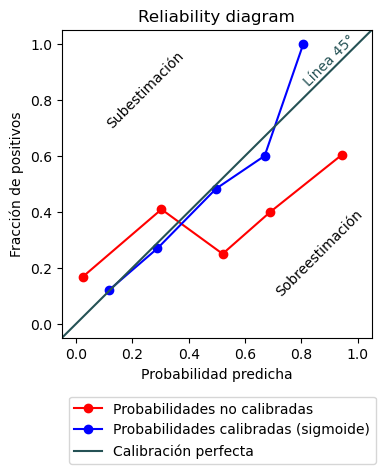

/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


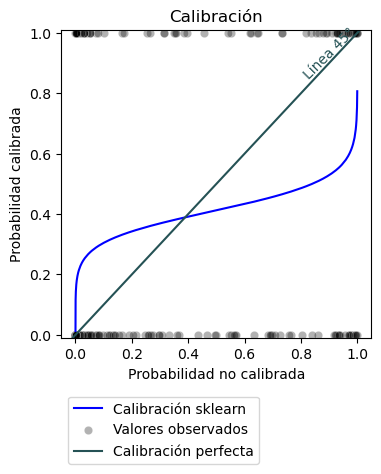

In [17]:
for i in models_dict.keys():
    display(Markdown(f"## {i}"))

    # Curvas de calibración
    pipe_sigmoid, _, preds = calibrate_model(
        pipe=models_dict.get(i), 
        X_valid=X_valid, y_valid=y_valid, 
        X_test=X_test, y_test=y_test,
        cal_sigmoid=True,
        cal_isotonic=False,
        model_name=i
    )
    plt.show()

    # Calibración 
    plot_calibration(
        preds=preds,
        y_pred_prob_calibrated='pred_sigmoid',
        model_name=i
    )
    plt.title('Calibración')
    plt.show()

    display(Markdown(f" "))

Intercept=0.35, Beta=-0.21


/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Intercepto=-1.5, Beta=2.1


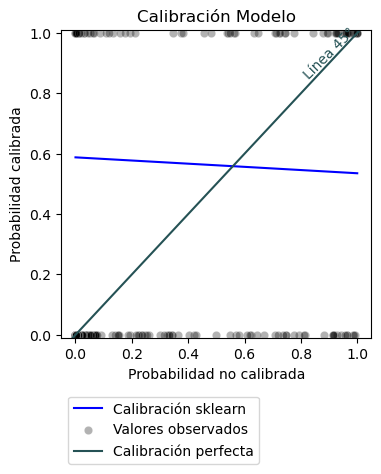

In [18]:
from scipy.special import expit
pipe_hist_cal = CalibratedClassifierCV(pipe_hist, method='sigmoid', cv='prefit')
pipe_hist_cal.fit(X_valid, y_valid)
A = pipe_hist_cal.calibrated_classifiers_[0].calibrators[0].a_
B = pipe_hist_cal.calibrated_classifiers_[0].calibrators[0].b_
print(f"Intercept={B:.2}, Beta={A:.2}")

df_preds = pd.DataFrame({
    "y_valid": y_valid,
    "y_valid_uncal": pipe_hist.predict_proba(X_valid)[:, 1],
    "y_valid_platt_sklearn":pipe_hist_cal.predict_proba(X_valid)[:,1]
}).assign(
     y_valid_platt_manual=lambda x: 1 / (1 + np.exp(-(A * x['y_valid_uncal'] + B)))
)

plot_calibration(
    preds=df_preds,
    y_obs='y_valid',
    y_pred_prob_calibrated='y_valid_platt_manual',
    y_pred_prob = 'y_valid_uncal',
    model_name='Modelo'
)

clf_log = LogisticRegression(random_state=42, C=1, fit_intercept=True)
# clf_log.fit(X=df_preds[['y_valid_uncal']], y=df_preds['y_valid'])
# beta = clf_log.coef_[0,0]
# intercepto=clf_log.intercept_[0]
# print(f"Intercepto={intercepto:.2}, Beta={beta:.2}")

# df_preds["y_valid_cal"] = clf_log.predict_proba(df_preds[["y_valid_uncal"]])[:, 1]
# plot_calibration(
#     preds=df_preds,
#     y_obs='y_valid',
#     y_pred_prob_calibrated='y_valid_cal',
#     y_pred_prob = 'y_valid_uncal',
#     model_name='Modelo'
# )

platt_lr = LogisticRegression(solver='lbfgs')
platt_lr.fit(pipe_hist.predict_proba(X_valid)[:, 1].reshape(-1, 1), y_valid)
beta = platt_lr.coef_[0,0]
intercepto=platt_lr.intercept_[0]
print(f"Intercepto={intercepto:.2}, Beta={beta:.2}")
# Calibrate the probabilities
y_valid_platt_manual = platt_lr.predict_proba(pipe_hist.predict_proba(X_valid)[:, 1].reshape(-1, 1))[:, 1]

# Compare with original and calibrated probabilities
df_preds = pd.DataFrame({
    "y_valid": y_valid,
    "y_valid_uncal": pipe_hist.predict_proba(X_valid)[:, 1],
    "y_valid_platt_sklearn": pipe_hist_cal.predict_proba(X_valid)[:, 1],
    "y_valid_platt_manual": y_valid_platt_manual
})

## Regresión logística

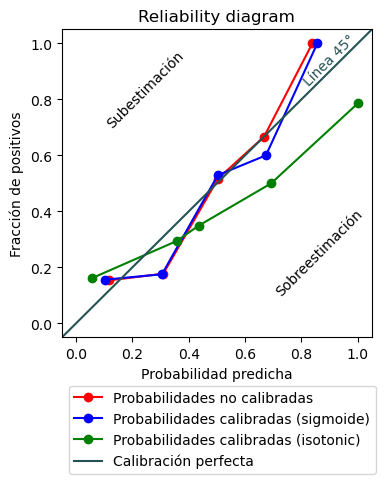

/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


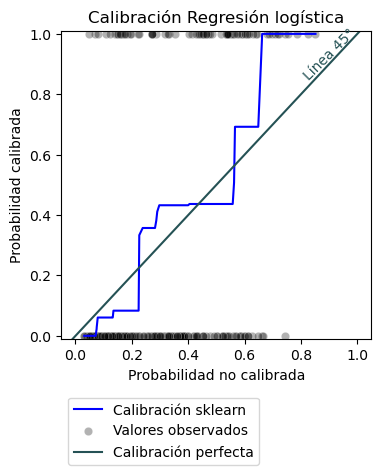

## Hist gradient boosting

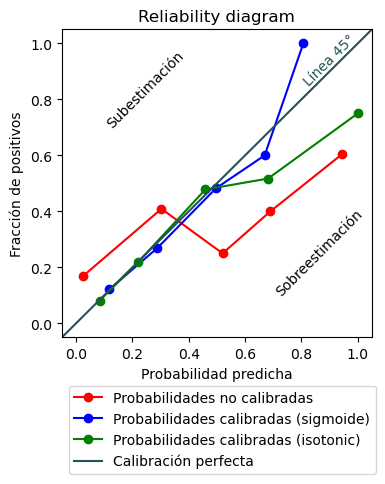

/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/quarto-env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


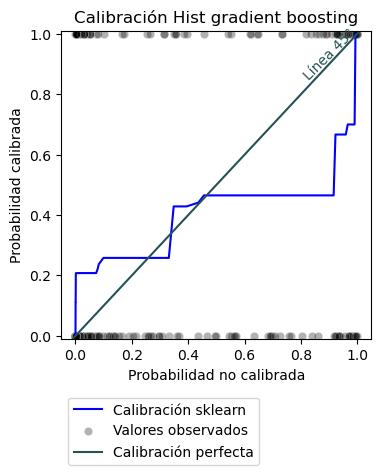

In [19]:
for i in models_dict.keys():
    display(Markdown(f"## {i}"))

    pipe_sigmoid, pipe_isotonic, preds = calibrate_model(
        pipe=models_dict.get(i), 
        X_valid=X_valid, y_valid=y_valid, 
        X_test=X_test, y_test=y_test,
        cal_sigmoid=True,
        cal_isotonic=True,
        model_name=i
    )
    plt.show()

    plot_calibration(preds=preds, y_pred_prob_calibrated='pred_isotonic', model_name=i)
    plt.show()

    display(Markdown(f" "))

In [20]:
metrics_df_sigmoid = pd.DataFrame()
metrics_df_isotonic = pd.DataFrame()
preds_dict = {}
for i in models_dict.keys():
    pipe = models_dict.get(i)
    _, _, preds = calibrate_model(
        pipe=models_dict.get(i), 
        X_valid=X_valid, y_valid=y_valid, 
        X_test=X_test, y_test=y_test,
        cal_sigmoid=True,
        cal_isotonic=True,
        model_name=i,
        plot_cal=False
    )
   
    m = calculate_clf_metrics(
        preds['y_obs'], preds['pred_class_sigmoid'], preds['pred_sigmoid'], 
        name=i
    ).reset_index().rename({'index':'Modelo'},axis=1)
    metrics_df_sigmoid = pd.concat([metrics_df_sigmoid, m], axis=0)

    m = calculate_clf_metrics(
        preds['y_obs'], preds['pred_class_sigmoid'], preds['pred_isotonic'], 
        name=i
    ).reset_index().rename({'index':'Modelo'},axis=1)
    metrics_df_isotonic = pd.concat([metrics_df_isotonic, m], axis=0)

In [21]:
metrics_df_all = pd.concat([
    metrics_df.assign(Modelo = lambda x: [f"{i} (pre calibración)" for i in x['Modelo']]), 
    metrics_df_sigmoid.assign(Modelo = lambda x: [f"{i} (calibración sigmoide)" for i in x['Modelo']])
],axis=0).sort_values('Modelo', ascending=False)

In [22]:
metrics_dfs = {
    'Modelo no calibrado': metrics_df,
    'Calibración sigmoide': metrics_df_sigmoid,
    'Calibración isotónica': metrics_df_isotonic,
    'No calibrados vs calibrados': metrics_df_all
}
for i in metrics_dfs.keys():
    display(Markdown(f"## {i}"))
    display(GT(metrics_dfs.get(i).round(2))
        .data_color(
            columns=['Accuracy','Precision','Recall','F1','ROC AUC'],
            palette=[color_verde_claro, color_verde]
        )
        .data_color(
            columns=['Log Loss','Brier Loss'], palette=['white', 'darkred']
        )
        .tab_spanner(
            label="Clasificación",
            columns=["Accuracy","Recall","Precision","F1"]
        )
        .tab_spanner(
            label="Ordenamiento",
            columns=["ROC AUC"]
        )
        .tab_spanner(
            label="Probabilidad",
            columns=["Log Loss", "Brier Loss"]
        )
    )
    display(Markdown(f" "))

## Modelo no calibrado

GT(_tbl_data=                   Modelo  Accuracy  Precision  Recall    F1  ROC AUC  \
0     Regresión logística      0.74       0.59    0.45  0.51     0.75   
0  Hist gradient boosting      0.72       0.53    0.53  0.53     0.74   

   Log Loss  Brier Loss  
0      0.53        0.18  
0      0.93        0.22  , _body=<great_tables._gt_data.Body object at 0x14216afe0>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Recall', type=<ColInfoTypeEnum.default: 1>, column_label='Recall', column_align='right', column_width=None), ColInfo(var='Precision', type=<ColInfoTypeEnum.default: 1>, column_label='Precision', column_align='right', column_width=None), ColInfo(var='F1', type=<ColInfoTypeEnum.default: 1>, column_label='F1', column_align='right', column_width=None), ColInfo(var='ROC AUC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC AUC', column_align='right', column_width=None), ColInfo(var='Log Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Log Loss', column_align='right', column_width=None), ColInfo(var='Brier Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Brier Loss', column_align='right', column_width=None)]), _stub=Stub([RowInfo(rownum_i=0, group_id=None, rowname=None, group_label=None, built=False), RowInfo(rownum_i=1, group_id=None, rowname=None, group_label=None, built=False)]), _row_groups=[], _group_rows=GroupRows([]), _spanners=Spanners([SpannerInfo(spanner_id='Clasificación', spanner_level=0, spanner_label='Clasificación', spanner_units=None, spanner_pattern=None, vars=['Accuracy', 'Recall', 'Precision', 'F1'], built=None), SpannerInfo(spanner_id='Ordenamiento', spanner_level=0, spanner_label='Ordenamiento', spanner_units=None, spanner_pattern=None, vars=['ROC AUC'], built=None), SpannerInfo(spanner_id='Probabilidad', spanner_level=0, spanner_label='Probabilidad', spanner_units=None, spanner_pattern=None, vars=['Log Loss', 'Brier Loss'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate

## Calibración sigmoide

GT(_tbl_data=                   Modelo  Accuracy  Precision  Recall    F1  ROC AUC  \
0     Regresión logística      0.74       0.58    0.45  0.51     0.75   
0  Hist gradient boosting      0.74       0.61    0.40  0.48     0.74   

   Log Loss  Brier Loss  
0      0.53        0.18  
0      0.53        0.18  , _body=<great_tables._gt_data.Body object at 0x141a5e050>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Recall', type=<ColInfoTypeEnum.default: 1>, column_label='Recall', column_align='right', column_width=None), ColInfo(var='Precision', type=<ColInfoTypeEnum.default: 1>, column_label='Precision', column_align='right', column_width=None), ColInfo(var='F1', type=<ColInfoTypeEnum.default: 1>, column_label='F1', column_align='right', column_width=None), ColInfo(var='ROC AUC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC AUC', column_align='right', column_width=None), ColInfo(var='Log Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Log Loss', column_align='right', column_width=None), ColInfo(var='Brier Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Brier Loss', column_align='right', column_width=None)]), _stub=Stub([RowInfo(rownum_i=0, group_id=None, rowname=None, group_label=None, built=False), RowInfo(rownum_i=1, group_id=None, rowname=None, group_label=None, built=False)]), _row_groups=[], _group_rows=GroupRows([]), _spanners=Spanners([SpannerInfo(spanner_id='Clasificación', spanner_level=0, spanner_label='Clasificación', spanner_units=None, spanner_pattern=None, vars=['Accuracy', 'Recall', 'Precision', 'F1'], built=None), SpannerInfo(spanner_id='Ordenamiento', spanner_level=0, spanner_label='Ordenamiento', spanner_units=None, spanner_pattern=None, vars=['ROC AUC'], built=None), SpannerInfo(spanner_id='Probabilidad', spanner_level=0, spanner_label='Probabilidad', spanner_units=None, spanner_pattern=None, vars=['Log Loss', 'Brier Loss'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate

## Calibración isotónica

GT(_tbl_data=                   Modelo  Accuracy  Precision  Recall    F1  ROC AUC  \
0     Regresión logística      0.74       0.58    0.45  0.51     0.74   
0  Hist gradient boosting      0.74       0.61    0.40  0.48     0.73   

   Log Loss  Brier Loss  
0      1.24        0.20  
0      0.95        0.18  , _body=<great_tables._gt_data.Body object at 0x141bfc580>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Recall', type=<ColInfoTypeEnum.default: 1>, column_label='Recall', column_align='right', column_width=None), ColInfo(var='Precision', type=<ColInfoTypeEnum.default: 1>, column_label='Precision', column_align='right', column_width=None), ColInfo(var='F1', type=<ColInfoTypeEnum.default: 1>, column_label='F1', column_align='right', column_width=None), ColInfo(var='ROC AUC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC AUC', column_align='right', column_width=None), ColInfo(var='Log Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Log Loss', column_align='right', column_width=None), ColInfo(var='Brier Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Brier Loss', column_align='right', column_width=None)]), _stub=Stub([RowInfo(rownum_i=0, group_id=None, rowname=None, group_label=None, built=False), RowInfo(rownum_i=1, group_id=None, rowname=None, group_label=None, built=False)]), _row_groups=[], _group_rows=GroupRows([]), _spanners=Spanners([SpannerInfo(spanner_id='Clasificación', spanner_level=0, spanner_label='Clasificación', spanner_units=None, spanner_pattern=None, vars=['Accuracy', 'Recall', 'Precision', 'F1'], built=None), SpannerInfo(spanner_id='Ordenamiento', spanner_level=0, spanner_label='Ordenamiento', spanner_units=None, spanner_pattern=None, vars=['ROC AUC'], built=None), SpannerInfo(spanner_id='Probabilidad', spanner_level=0, spanner_label='Probabilidad', spanner_units=None, spanner_pattern=None, vars=['Log Loss', 'Brier Loss'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Precision', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Recall', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate

## No calibrados vs calibrados

GT(_tbl_data=                                          Modelo  Accuracy  Precision  Recall  \
0          Regresión logística (pre calibración)      0.74       0.59    0.45   
0     Regresión logística (calibración sigmoide)      0.74       0.58    0.45   
0       Hist gradient boosting (pre calibración)      0.72       0.53    0.53   
0  Hist gradient boosting (calibración sigmoide)      0.74       0.61    0.40   

     F1  ROC AUC  Log Loss  Brier Loss  
0  0.51     0.75      0.53        0.18  
0  0.51     0.75      0.53        0.18  
0  0.53     0.74      0.93        0.22  
0  0.48     0.74      0.53        0.18  , _body=<great_tables._gt_data.Body object at 0x142169e70>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Recall', type=<ColInfoTypeEnum.default: 1>, column_label='Recall', column_align='right', column_width=None), ColInfo(var='Precision', type=<ColInfoTypeEnum.default: 1>, column_label='Precision', column_align='right', column_width=None), ColInfo(var='F1', type=<ColInfoTypeEnum.default: 1>, column_label='F1', column_align='right', column_width=None), ColInfo(var='ROC AUC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC AUC', column_align='right', column_width=None), ColInfo(var='Log Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Log Loss', column_align='right', column_width=None), ColInfo(var='Brier Loss', type=<ColInfoTypeEnum.default: 1>, column_label='Brier Loss', column_align='right', column_width=None)]), _stub=Stub([RowInfo(rownum_i=0, group_id=None, rowname=None, group_label=None, built=False), RowInfo(rownum_i=1, group_id=None, rowname=None, group_label=None, built=False), RowInfo(rownum_i=2, group_id=None, rowname=None, group_label=None, built=False), RowInfo(rownum_i=3, group_id=None, rowname=None, group_label=None, built=False)]), _row_groups=[], _group_rows=GroupRows([]), _spanners=Spanners([SpannerInfo(spanner_id='Clasificación', spanner_level=0, spanner_label='Clasificación', spanner_units=None, spanner_pattern=None, vars=['Accuracy', 'Recall', 'Precision', 'F1'], built=None), SpannerInfo(spanner_id='Ordenamiento', spanner_level=0, spanner_label='Ordenamiento', spanner_units=None, spanner_pattern=None, vars=['ROC AUC'], built=None), SpannerInfo(spanner_id='Probabilidad', spanner_level=0, spanner_label='Probabilidad', spanner_units=None, spanner_pattern=None, vars=['Log Loss', 'Brier Loss'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#bdcbcc')]), StyleInfo(locname='data', locnum=5, grpname=None, colname='Accuracy', rownum=3, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#255255')]), StyleInfo(locname='data', locnum=5, grpname=None, co

In [23]:
for i in models_dict.keys():
    display(Markdown(f"## {i}"))
    _, _, preds = calibrate_model(
        pipe=models_dict.get(i), 
        X_valid=X_valid, y_valid=y_valid, 
        X_test=X_test, y_test=y_test,
        cal_sigmoid=True,
        cal_isotonic=True,
        model_name=i,
        plot_cal=False
    )
    display(Markdown('Modelo no calibrado'))
    calibration_table(preds=preds, bins=5, title='Modelo no calibrado')
    display(Markdown('Modelo calibrado (sigmoide)'))
    calibration_table(preds=preds, pred_column='pred_sigmoid', bins=5, title='Modelo calibrado (sigmoide)')
    display(Markdown(f" "))

## Regresión logística

Modelo no calibrado

/Users/karinabartolome/Documents/GitHub/workshops/20240910-uba-calibracion/functions.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preds.groupby("Bin", as_index=False)


Bin,N,N Clase 1,Probabilidadpromedio,% Clase 1(observado),Diferencia |avg prob - % clase 1|
"(2.99%, 11.90%]",50,4,8.00%,8.00%,0.00%
"(11.90%, 19.60%]",50,11,15.00%,22.00%,7.00%
"(19.60%, 35.60%]",50,12,28.00%,24.00%,4.00%
"(35.60%, 53.40%]",50,16,44.00%,32.00%,12.00%
"(53.40%, 85.20%]",50,32,62.00%,64.00%,2.00%


Modelo calibrado (sigmoide)

...

/Users/karinabartolome/Documents/GitHub/workshops/20240910-uba-calibracion/functions.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preds.groupby("Bin", as_index=False)


Bin,N,N Clase 1,Probabilidadpromedio,% Clase 1(observado),Diferencia |avg prob - % clase 1|
"(-0.10%, 0.12%]",50,4,0.00%,8.00%,8.00%
"(0.12%, 1.75%]",50,7,1.00%,14.00%,13.00%
"(1.75%, 22.80%]",50,14,8.00%,28.00%,20.00%
"(22.80%, 83.70%]",50,20,51.00%,40.00%,11.00%
"(83.70%, 100.00%]",50,30,95.00%,60.00%,35.00%


Modelo calibrado (sigmoide)

/Users/karinabartolome/Documents/GitHub/workshops/20240910-uba-calibracion/functions.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preds.groupby("Bin", as_index=False)


Bin,N,N Clase 1,Probabilidadpromedio,% Clase 1(observado),Diferencia |avg prob - % clase 1|
"(1.20%, 14.10%]",50,4,9.00%,8.00%,1.00%
"(14.10%, 22.80%]",50,7,18.00%,14.00%,4.00%
"(22.80%, 35.00%]",50,14,28.00%,28.00%,0.00%
"(35.00%, 49.90%]",50,20,41.00%,40.00%,1.00%
"(49.90%, 80.70%]",50,30,60.00%,60.00%,0.00%
